# Molecular Graph Visualizer

In [1]:
import sys
sys.path.insert(0, '..')

from src import parse_smiles
from src.chem.atomic import Atom, BracketAtom
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.figsize'] = (10, 8)

Parser debugging for SmilesParser written to parser.out


In [2]:
_, graph, _ = parse_smiles('CC(C)C')
graph.adjacency_list

{Atom(symbol='C', aromatic=False): [(Atom(symbol='C', aromatic=False), '-')],
 Atom(symbol='C', aromatic=False): [(Atom(symbol='C', aromatic=False), '-'),
  (Atom(symbol='C', aromatic=False), '-'),
  (Atom(symbol='C', aromatic=False), '-')],
 Atom(symbol='C', aromatic=False): [(Atom(symbol='C', aromatic=False), '-')],
 Atom(symbol='C', aromatic=False): [(Atom(symbol='C', aromatic=False), '-')]}

In [3]:
# Atom colors by element
ATOM_COLORS = {
    'C': '#404040', 'N': '#3050F8', 'O': '#FF0D0D', 'S': '#FFFF30',
    'P': '#FF8000', 'F': '#90E050', 'CL': '#1FF01F', 'BR': '#A62929',
    'I': '#940094', 'H': '#FFFFFF', 'B': '#FFB5B5', 'SI': '#F0C8A0',
}

# Bond styles
BOND_STYLES = {
    '-': {'style': 'solid', 'width': 2, 'label': 'Single'},
    '=': {'style': 'solid', 'width': 4, 'label': 'Double'},
    '#': {'style': 'solid', 'width': 6, 'label': 'Triple'},
    ':': {'style': 'dashed', 'width': 2, 'label': 'Aromatic'},
    '/': {'style': 'solid', 'width': 2, 'label': 'Up'},
    '\\': {'style': 'solid', 'width': 2, 'label': 'Down'},
}

def get_atom_color(atom):
    symbol = atom.symbol.upper()
    return ATOM_COLORS.get(symbol, '#808080')

def get_atom_label(atom):
    label = atom.symbol
    if isinstance(atom, BracketAtom):
        if atom.hcount:
            label += f'H{atom.hcount}' if atom.hcount > 1 else 'H'
        if atom.charge:
            label += f'{atom.charge:+d}'
    if getattr(atom, 'aromatic', False):
        label = label.lower()
    return label

In [4]:
def molecular_graph_to_nx(mol_graph):
    """Convert MolecularGraph to NetworkX graph."""
    G = nx.Graph()
    
    # Add nodes
    for i, atom in enumerate(mol_graph.adjacency_list.keys()):
        G.add_node(atom.atom_id, 
                   label=get_atom_label(atom),
                   symbol=atom.symbol,
                   color=get_atom_color(atom),
                   aromatic=getattr(atom, 'aromatic', False))
    
    # Add edges
    seen_edges = set()
    for atom, neighbors in mol_graph.adjacency_list.items():
        for neighbor, bond_type in neighbors:
            edge_key = tuple(sorted([atom.atom_id, neighbor.atom_id]))
            if edge_key not in seen_edges:
                seen_edges.add(edge_key)
                G.add_edge(atom.atom_id, neighbor.atom_id, bond=bond_type)
    
    return G

In [5]:
def visualize_smiles(smiles, title=None, ax=None):
    """Parse and visualize a SMILES string."""
    is_valid, graph, error = parse_smiles(smiles)
    
    if not is_valid:
        print(f"Failed to parse: {smiles}")
        print(f"Error: {error}")
        return None
    
    G = molecular_graph_to_nx(graph)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    # Layout
    if len(G.nodes) < 20:
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw edges by bond type
    for bond_type, style in BOND_STYLES.items():
        edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('bond') == bond_type]
        if edges:
            nx.draw_networkx_edges(G, pos, edgelist=edges, ax=ax,
                                   style=style['style'], width=style['width'],
                                   edge_color='#555555', alpha=0.8)
    
    # Draw nodes
    node_colors = [G.nodes[n]['color'] for n in G.nodes]
    node_sizes = [800 if G.nodes[n]['symbol'] != 'H' else 400 for n in G.nodes]
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, 
                           node_size=node_sizes, edgecolors='black', linewidths=1.5)
    
    # Draw labels
    labels = {n: G.nodes[n]['label'] for n in G.nodes}
    label_colors = {n: 'white' if G.nodes[n]['symbol'] in ['C', 'N', 'BR', 'I'] else 'black' for n in G.nodes}
    
    for node, (x, y) in pos.items():
        ax.text(x, y, labels[node], ha='center', va='center', 
                fontsize=10, fontweight='bold', color=label_colors[node])
    
    ax.set_title(title or smiles, fontsize=12, fontweight='bold')
    ax.axis('off')
    
    return G

## Simple Molecules

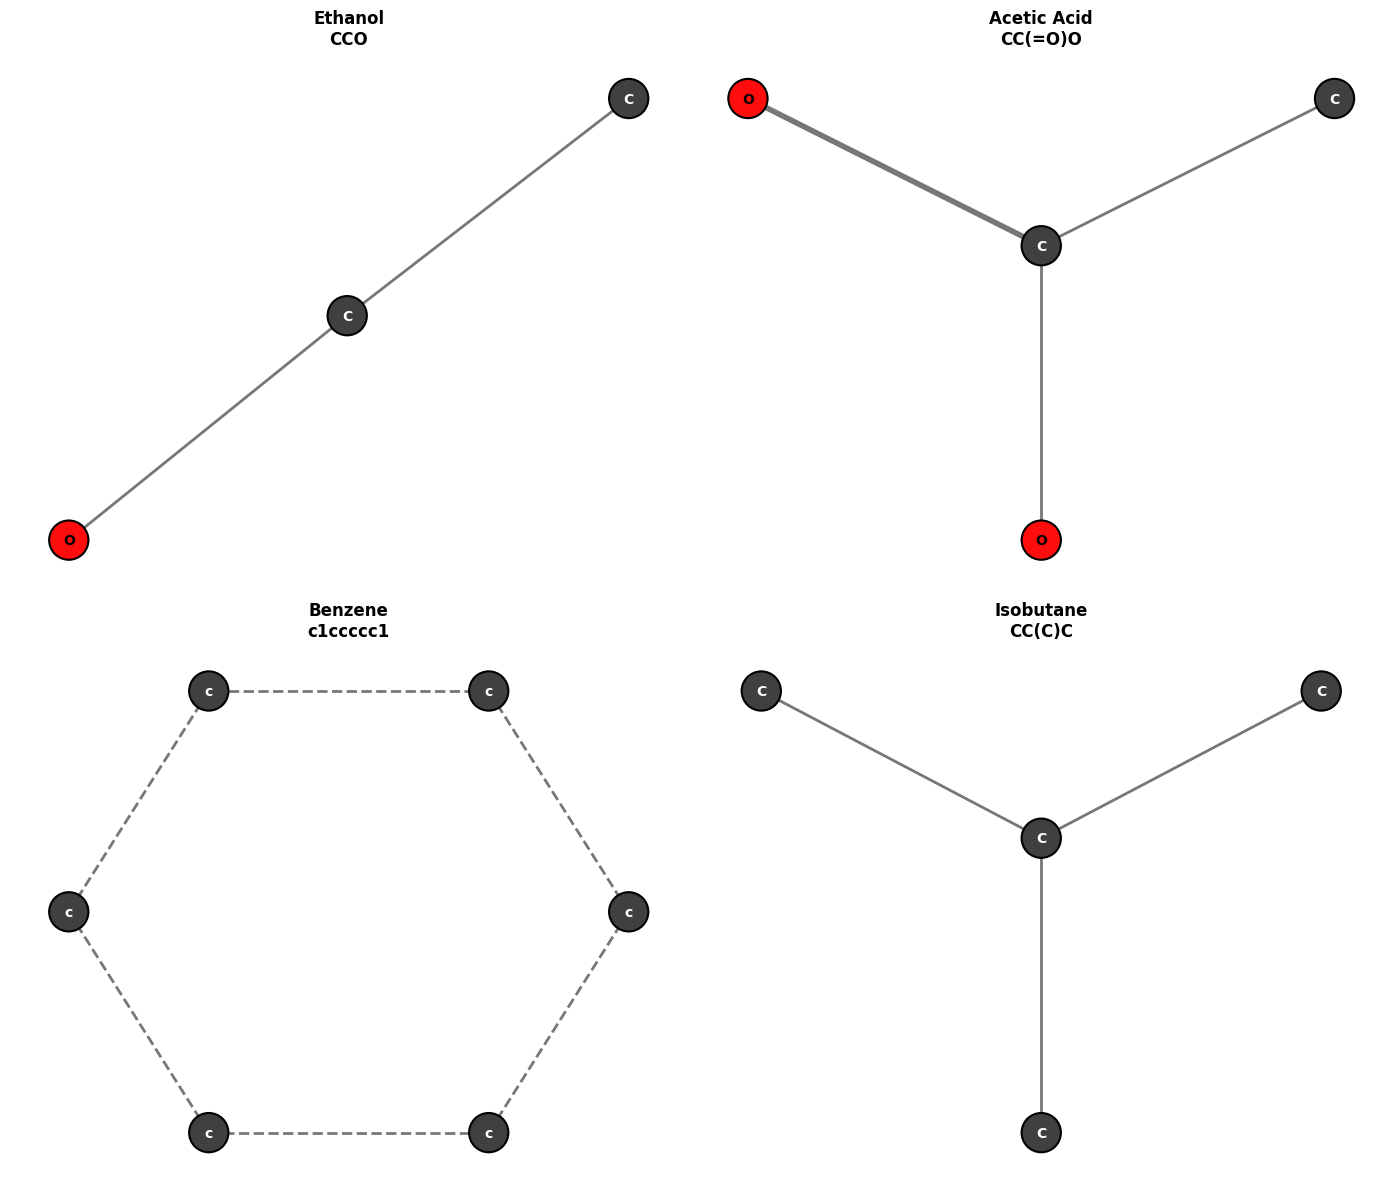

In [6]:
simple_molecules = [
    ('CCO', 'Ethanol'),
    ('CC(=O)O', 'Acetic Acid'),
    ('c1ccccc1', 'Benzene'),
    ('CC(C)C', 'Isobutane'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (smiles, name) in zip(axes.flatten(), simple_molecules):
    visualize_smiles(smiles, f"{name}\n{smiles}", ax)
plt.tight_layout()
plt.savefig('simple_molecules.png', dpi=150)
plt.show()

## Aromatic Compounds

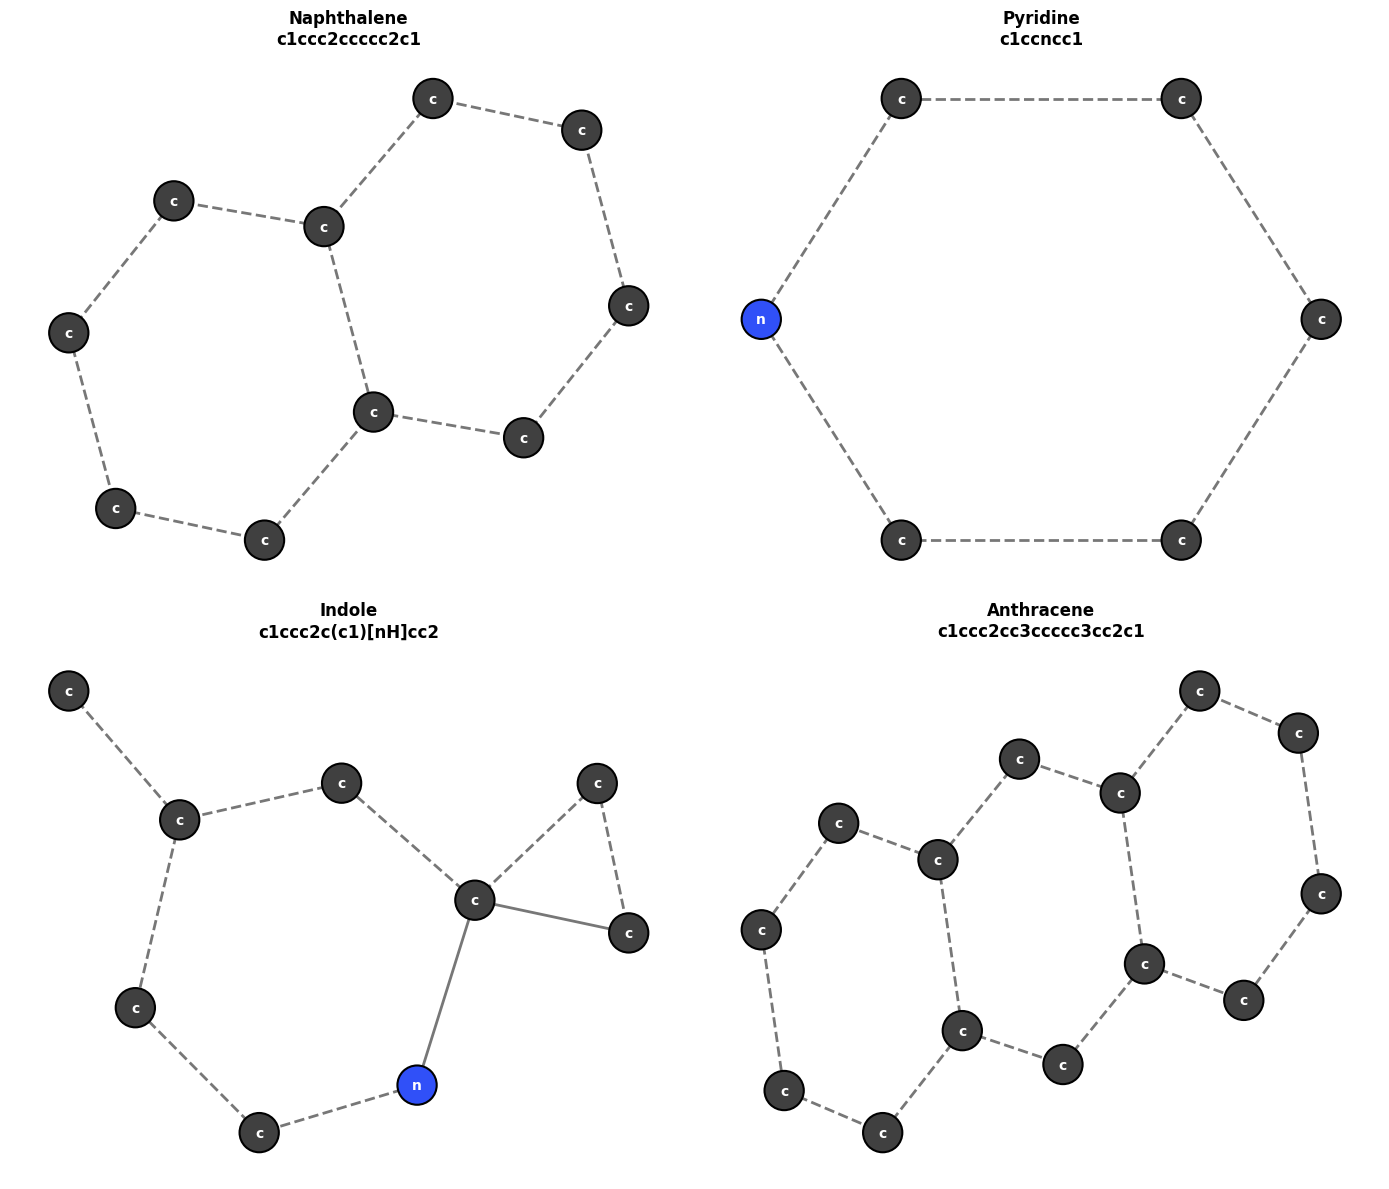

In [7]:
aromatic = [
    ('c1ccc2ccccc2c1', 'Naphthalene'),
    ('c1ccncc1', 'Pyridine'),
    ('c1ccc2c(c1)[nH]cc2', 'Indole'),
    ('c1ccc2cc3ccccc3cc2c1', 'Anthracene'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (smiles, name) in zip(axes.flatten(), aromatic):
    visualize_smiles(smiles, f"{name}\n{smiles}", ax)
plt.tight_layout()
plt.savefig('aromatic_compounds.png', dpi=150)
plt.show()

## Functional Groups

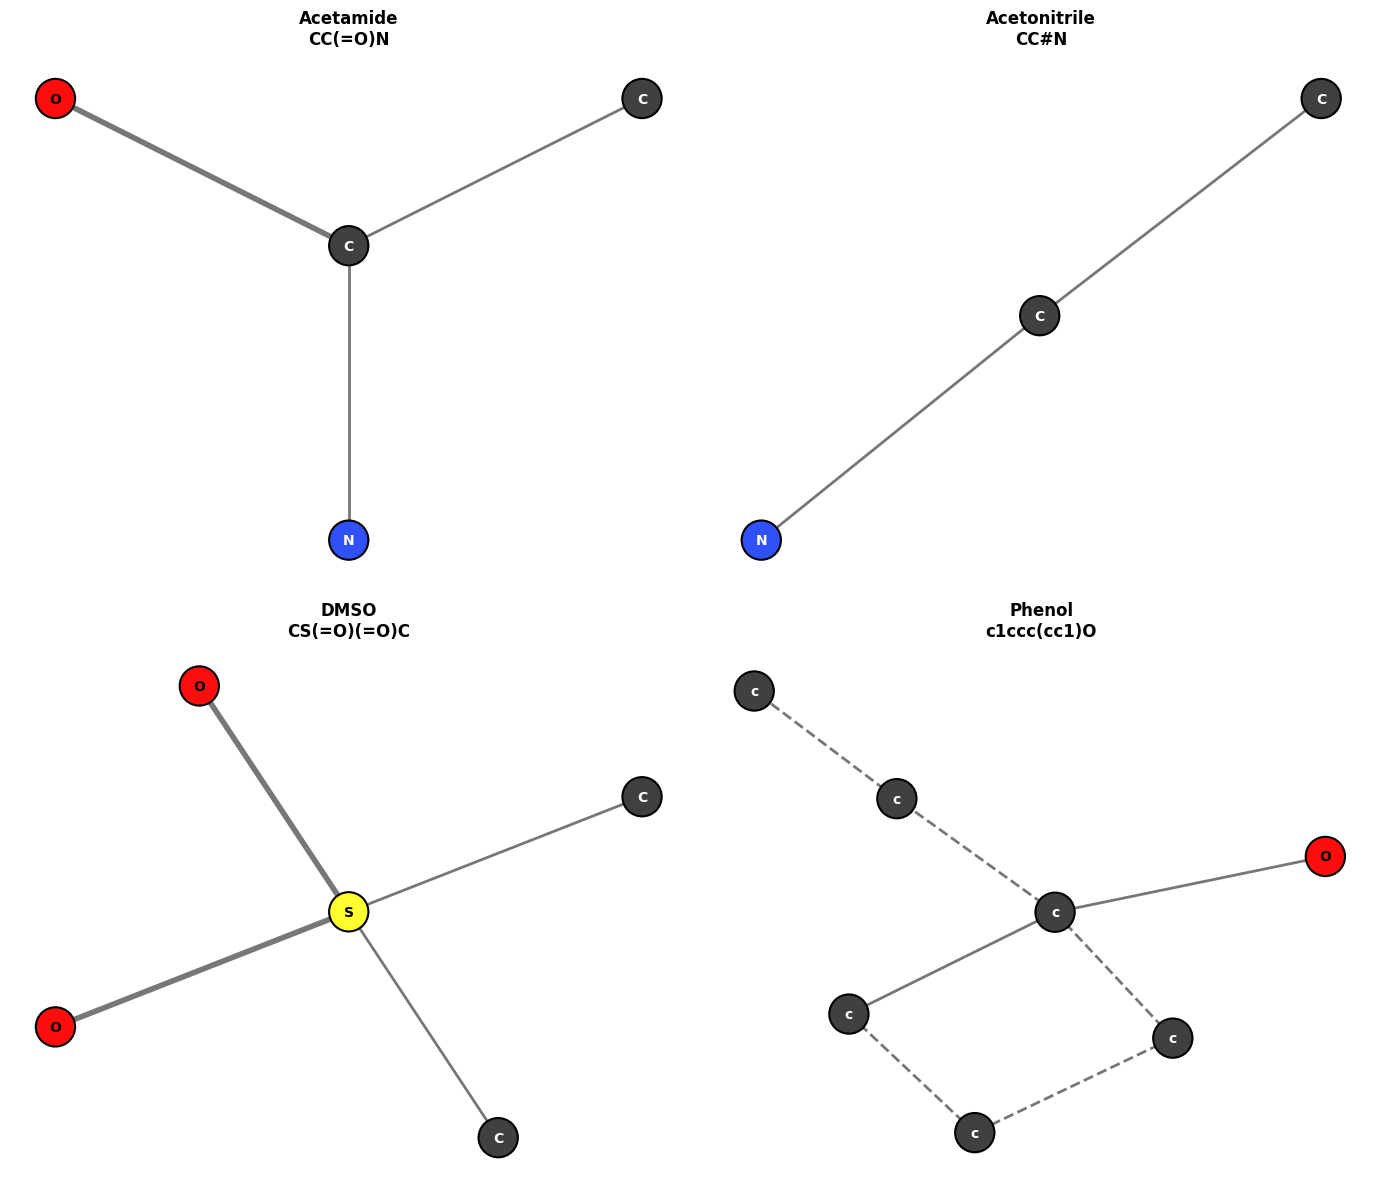

In [8]:
functional = [
    ('CC(=O)N', 'Acetamide'),
    ('CC#N', 'Acetonitrile'),
    ('CS(=O)(=O)C', 'DMSO'),
    ('c1ccc(cc1)O', 'Phenol'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (smiles, name) in zip(axes.flatten(), functional):
    visualize_smiles(smiles, f"{name}\n{smiles}", ax)
plt.tight_layout()
plt.savefig('functional_groups.png', dpi=150)
plt.show()

## Interactive Visualization

In [9]:
def visualize_with_stats(smiles):
    """Visualize and print graph statistics."""
    is_valid, graph, error = parse_smiles(smiles)
    
    if not is_valid:
        print(f"Failed: {error}")
        return
    
    G = molecular_graph_to_nx(graph)
    
    print(f"SMILES: {smiles}")
    print(f"Atoms: {G.number_of_nodes()}")
    print(f"Bonds: {G.number_of_edges()}")
    print(f"Cycles: {len(graph.cycles)}")
    
    # Bond type counts
    bond_counts = {}
    for u, v, d in G.edges(data=True):
        bond = d.get('bond', '-')
        bond_counts[bond] = bond_counts.get(bond, 0) + 1
    print(f"Bond types: {bond_counts}")
    
    # Atom counts
    atom_counts = {}
    for n in G.nodes:
        sym = G.nodes[n]['symbol']
        atom_counts[sym] = atom_counts.get(sym, 0) + 1
    print(f"Atom types: {atom_counts}")
    print()
    
    visualize_smiles(smiles)
    plt.show()

SMILES: c1ccc2c(c1)ccc3ccccc23
Atoms: 14
Bonds: 16
Cycles: 3
Bond types: {':': 14, '-': 2}
Atom types: {'C': 14}



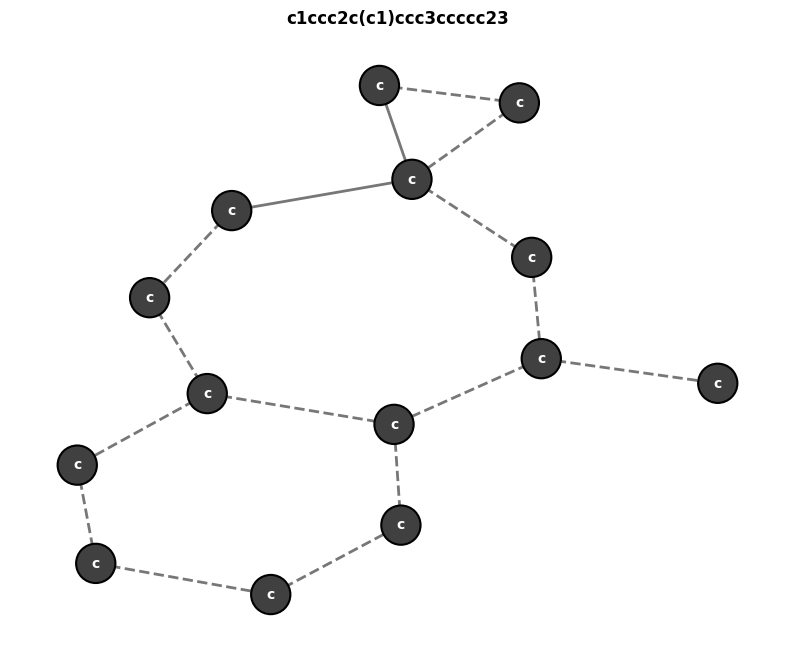

In [10]:
# Try your own SMILES
visualize_with_stats('c1ccc2c(c1)ccc3ccccc23')  # Phenanthrene

## Graph Properties Analysis

In [11]:
def analyze_graph(smiles):
    """Analyze graph properties."""
    is_valid, graph, _ = parse_smiles(smiles)
    if not is_valid:
        return None
    
    G = molecular_graph_to_nx(graph)
    
    return {
        'smiles': smiles,
        'nodes': G.number_of_nodes(),
        'edges': G.number_of_edges(),
        'cycles': len(graph.cycles),
        'density': nx.density(G),
        'avg_degree': sum(dict(G.degree()).values()) / G.number_of_nodes() if G.number_of_nodes() > 0 else 0,
        'is_connected': nx.is_connected(G),
    }

molecules = [
    'C', 'CC', 'CCC', 'CCCC',
    'c1ccccc1', 'c1ccc2ccccc2c1', 'c1ccc2cc3ccccc3cc2c1',
    'CCO', 'CC(=O)O', 'CC(=O)N',
]

import pandas as pd
results = [analyze_graph(s) for s in molecules]
results = [r for r in results if r is not None]
df = pd.DataFrame(results)
display(df)

,smiles,nodes,edges,cycles,density,avg_degree,is_connected
0,C,1,0,0,0.000000,0.000000,True
1,CC,2,1,0,1.000000,1.000000,True
2,CCC,3,2,0,0.666667,1.333333,True
3,CCCC,4,3,0,0.500000,1.500000,True
4,c1ccccc1,6,6,1,0.400000,2.000000,True
5,c1ccc2ccccc2c1,10,11,2,0.244444,2.200000,True
6,c1ccc2cc3ccccc3cc2c1,14,16,3,0.175824,2.285714,True
7,CCO,3,2,0,0.666667,1.333333,True
8,CC(=O)O,4,3,0,0.500000,1.500000,True
9,CC(=O)N,4,3,0,0.500000,1.500000,True


## Legend

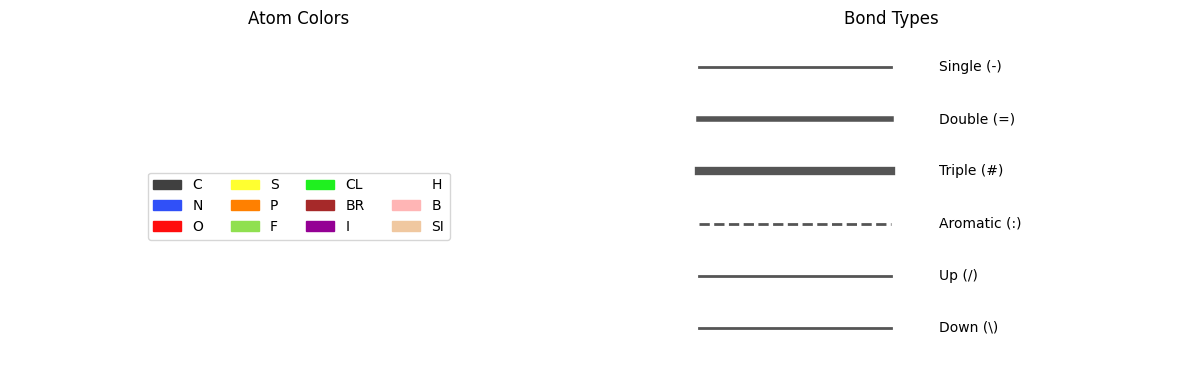

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Atom colors legend
patches = [mpatches.Patch(color=color, label=symbol) for symbol, color in ATOM_COLORS.items()]
ax1.legend(handles=patches, loc='center', ncol=4, fontsize=10)
ax1.set_title('Atom Colors')
ax1.axis('off')

# Bond types legend
y = 0.9
for bond, style in BOND_STYLES.items():
    linestyle = '--' if style['style'] == 'dashed' else '-'
    ax2.plot([0.1, 0.3], [y, y], linestyle=linestyle, linewidth=style['width'], color='#555555')
    ax2.text(0.35, y, f"{style['label']} ({bond})", va='center', fontsize=10)
    y -= 0.15
ax2.set_xlim(0, 0.6)
ax2.set_ylim(0, 1)
ax2.set_title('Bond Types')
ax2.axis('off')

plt.tight_layout()
plt.savefig('legend.png', dpi=150)
plt.show()